In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import umap
adata_public =sc.read('/Users/guanchenwu/OneDrive/HKU PhD/Figure 4 new/scRNA/adata_combined.h5ad')
adata_public

/opt/anaconda3/envs/sc_ana/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 47604 × 25850
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'sample_batch', 'leiden', 'celltype', 'celltype_v2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'celltype_v2_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_batch_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

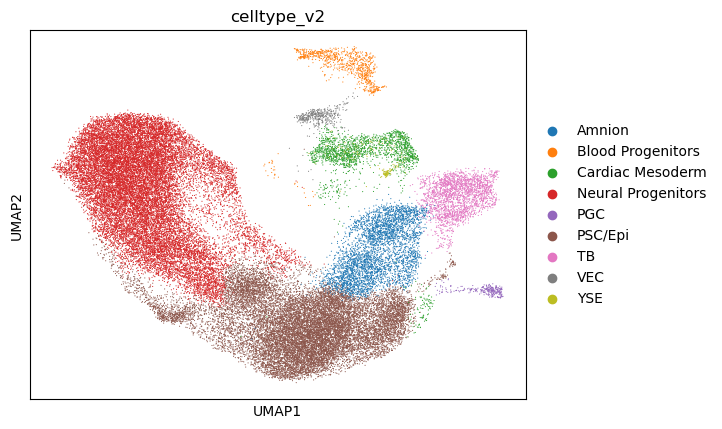

In [3]:
sc.pl.umap(adata_public, color="celltype_v2")

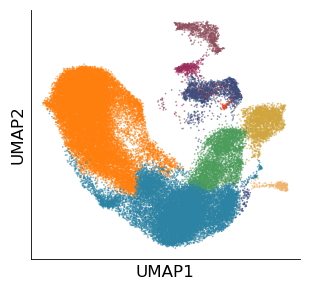

In [5]:
import scanpy as sc
import matplotlib.pyplot as plt

# Define custom color mapping for clusters
cluster_colors = {
    'Neural Progenitors': '#ff7f0e',  # Soft Green
    'Amnion': '#4C9C5B',              # Warm Yellow
    'PSC/Epi': '#2D83A3',             # Soft Blue
    'VEC': '#9C2C5B',                 # Muted Red
    'TB': '#D1A53D',                  # Earthy Gold
    'Blood Progenitors': '#8F4F5C',   # Dusky Pink
    'Cardiac Mesoderm': '#3C4C7C',    # Calm Navy Blue
    'PGC': '#F1B46B',                 # Light Orange
    'YSE': '#EE4B2B'                  # Subtle Teal
}

# Load your data (already assuming adata_public is loaded)
# Plot UMAP with custom cluster colors
fig, ax = plt.subplots(figsize=(3.2, 3.0))

# Create the UMAP plot with the custom color mapping
sc.pl.umap(adata_public, 
           color='celltype_v2', 
           palette=cluster_colors, 
           ax=ax, 
           legend_loc=None,
           alpha=0.6, 
           size=6,
           show=False)
ax.set_title("")

ax.set_xlabel("UMAP1", fontsize=12)
ax.set_ylabel("UMAP2", fontsize=12)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=10,     # axis text size
    width=1,        # tick thickness
    length=3
)

# Spine thickness (Nature style)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.show()
plt.savefig(
    "Fig4_UMAP_whole_edit_6.tiff",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

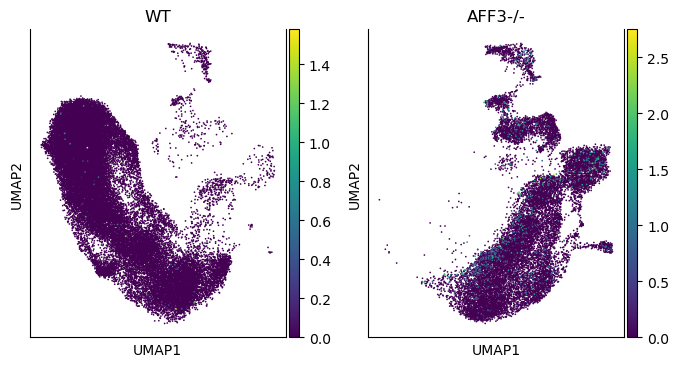

In [6]:
import scanpy as sc
import matplotlib.pyplot as plt

# -------------------------------
# 1. Define WT vs AFF3-/- (KO)
# -------------------------------
adata_public.obs["genotype"] = (
    adata_public.obs["sample"]
    .astype(str)
    .map(lambda x: "WT" if x.startswith("WT") else "AFF3-/-")
    .astype("category")
)

# -------------------------------
# 2. Subset data
# -------------------------------
adata_WT = adata_public[adata_public.obs["genotype"] == "WT"].copy()
adata_KO = adata_public[adata_public.obs["genotype"] == "AFF3-/-"].copy()

# -------------------------------
# 3. Plot: two UMAPs, XIST only
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sc.pl.umap(
    adata_WT,
    color="XIST",
    use_raw=False,
    cmap="viridis",
    size=6,
    ax=axes[0],
    show=False,
    title="WT"
)

sc.pl.umap(
    adata_KO,
    color="XIST",
    use_raw=False,
    cmap="viridis",
    size=6,
    ax=axes[1],
    show=False,
    title="AFF3-/-"
)

# clean, figure-style axes
for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.spines["top"].set_visible(False)
    ax.spines["right"]


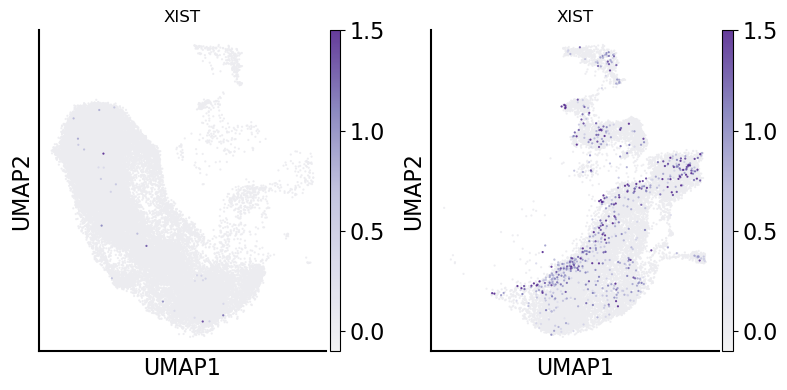

In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------
# 1) Define genotype (WT vs AFF3-/-)
# -------------------------------
adata_public.obs["genotype"] = (
    adata_public.obs["sample"]
    .astype(str)
    .map(lambda x: "WT" if x.startswith("WT") else "AFF3-/-")
    .astype("category")
)

adata_WT = adata_public[adata_public.obs["genotype"] == "WT"].copy()
adata_KO = adata_public[adata_public.obs["genotype"] == "AFF3-/-"].copy()

# -------------------------------
# 2) Colormap
# -------------------------------
xist_cmap = LinearSegmentedColormap.from_list(
    "xist_purple_high",
    [
        "#f2f2f2",
        "#dadaeb",
        "#bcbddc",
        "#807dba",
        "#54278f"
    ]
)

# -------------------------------
# 3) Fixed scaling
# -------------------------------
VMIN = -0.1
VMAX = 1.5

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sc.pl.umap(
    adata_WT,
    color="XIST",
    cmap=xist_cmap,
    vmin=VMIN,
    vmax=VMAX,
    size=10,
    alpha=0.9,
    ax=axes[0],
    show=False
)

sc.pl.umap(
    adata_KO,
    color="XIST",
    cmap=xist_cmap,
    vmin=VMIN,
    vmax=VMAX,
    size=10,
    alpha=0.9,
    ax=axes[1],
    show=False
)

ax.set_title("")

for ax in axes:
    # bigger axis label text
    ax.set_xlabel("UMAP1", fontsize=16)
    ax.set_ylabel("UMAP2", fontsize=16)

    cbar = ax.collections[0].colorbar
    cbar.set_ticks([0, 0.5, 1.0, 1.5])
    cbar.ax.tick_params(labelsize=16)

    # bigger tick labels + thicker ticks
    ax.tick_params(
        axis="both",
        which="both",
        labelsize=12,
        width=1.5,
        length=4
    )

    # thicker existing axes only (left & bottom)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    # keep original look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    "Fig4_XIST_UMAP_WT_vs_AFF3KO.tiff",
    dpi=600,
    format="tiff",
    bbox_inches="tight"
)
plt.show()